<a href="https://colab.research.google.com/github/chetnasharma18/Indian-Election-Prediction/blob/main/Indian_Election_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
def load_data(path_2019, path_2024):
    df2019 = pd.read_csv(path_2019)
    df2024 = pd.read_csv(path_2024)

    df = pd.concat([df2019, df2024], ignore_index=True)
    print("✅ Data Loaded Successfully")
    print(df.head())
    return df

In [ ]:
def clean_data(df):
    df = df.drop_duplicates()
    df = df.dropna()

    df['Party'] = df['Party'].str.replace("Bharatiya Janata Party", "BJP")

    print("✅ Data Cleaning Completed")
    return df


In [ ]:
def feature_engineering(df):
    past_vote = df[df['Year'] == 2019].groupby('Constituency')['VoteShare'].max()
    df['PrevMaxPartyShare'] = df['Constituency'].map(past_vote)

    print("✅ Feature Engineering Done")
    return df

In [ ]:
def prepare_data(df):
    features = ['PrevMaxPartyShare', 'Turnout', 'Incumbent', 'UrbanPerc']

    X = df[features]
    y = (df['WinningParty'] == "BJP").astype(int)

    X_train = X[df['Year'] == 2019]
    y_train = y[df['Year'] == 2019]

    X_test = X[df['Year'] == 2024]
    y_test = y[df['Year'] == 2024]

    print("✅ Data Prepared")
    return X_train, X_test, y_train, y_test, df

In [ ]:
def train_model(X_train, y_train):
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=4,
        random_state=42
    )

    model.fit(X_train, y_train)
    print("✅ Model Training Completed")
    return model

In [ ]:
def evaluate_model(model, X_test, y_test, df):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n🎯 Accuracy: {accuracy:.4f}")

    print("\n📊 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Results table (from Code 1)
    results = df[df['Year'] == 2024].copy()
    results['Predicted_BJP_Win'] = y_pred
    results['Actual_BJP_Win'] = y_test.values

    print("\nPrediction Results Table:")
    print(results[['Constituency','PrevMaxPartyShare','Turnout','Predicted_BJP_Win','Actual_BJP_Win']])

    cm = confusion_matrix(y_test, y_pred)
    return y_pred, cm

In [ ]:
def visualize_results(cm, y_test, y_pred):
    # Confusion Matrix
    cm_table = pd.DataFrame(
        cm,
        columns=['Predicted Non-BJP','Predicted BJP'],
        index=['Actual Non-BJP','Actual BJP']
    )

    print("\nConfusion Matrix:")
    print(cm_table)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_table, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

    # Accuracy Bar Chart
    correct = np.sum(y_pred == y_test)
    incorrect = np.sum(y_pred != y_test)

    plt.figure(figsize=(6, 4))
    plt.bar(['Correct Predictions','Incorrect Predictions'], [correct, incorrect])
    plt.title("Model Performance")
    plt.ylabel("Count")
    plt.show()

    # ML Pipeline Diagram (from Code 1)
    steps = [
        "Load Dataset",
        "Merge Data",
        "Data Cleaning",
        "Feature Engineering",
        "Feature Selection",
        "Train Random Forest",
        "Prediction",
        "Evaluation"
    ]

    plt.figure(figsize=(8,6))
    for i, step in enumerate(steps):
        plt.text(0.5, 1-i*0.1, step, ha='center',
                 bbox=dict(boxstyle="round", fc="lightblue"))

    plt.axis('off')
    plt.title("Machine Learning Pipeline Flow Diagram")
    plt.show()

In [ ]:
def feature_importance(model, feature_names):
    importance = model.feature_importances_

    feat_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)

    print("\n📌 Feature Importance:")
    print(feat_df)

    plt.figure(figsize=(8, 5))
    sns.barplot(x='Importance', y='Feature', data=feat_df)
    plt.title("Feature Importance")
    plt.show()

✅ Data Loaded Successfully
   Year Constituency                   Party  VoteShare WinningParty  Turnout  \
0  2019     Amritsar  Bharatiya Janata Party         45          BJP       67   
1  2019     Amritsar                     INC         40          BJP       67   
2  2019     Ludhiana  Bharatiya Janata Party         48          BJP       65   
3  2019     Ludhiana                     INC         42          BJP       65   
4  2019      Patiala                     INC         50          INC       69   

   Incumbent  UrbanPerc  
0          1         70  
1          0         70  
2          1         75  
3          0         75  
4          1         60  
✅ Data Cleaning Completed
✅ Feature Engineering Done
✅ Data Prepared
✅ Model Training Completed

🎯 Accuracy: 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4

    accuracy            

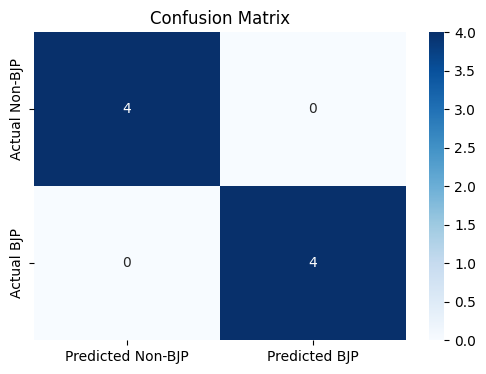

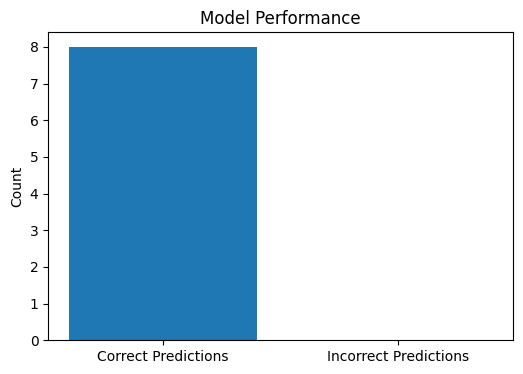

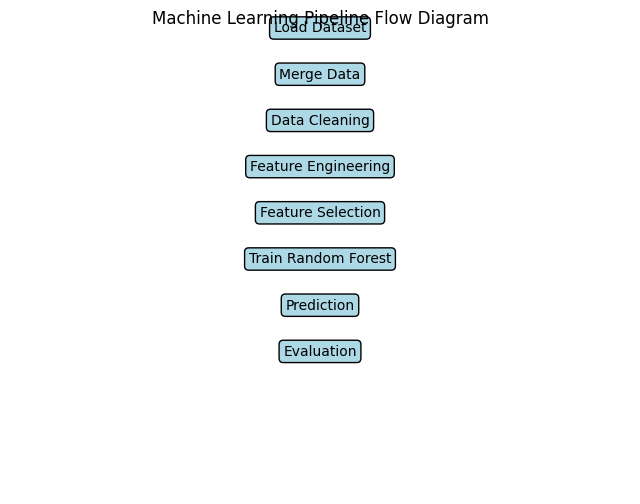


📌 Feature Importance:
             Feature  Importance
1            Turnout    0.363636
0  PrevMaxPartyShare    0.348485
3          UrbanPerc    0.282828
2          Incumbent    0.005051


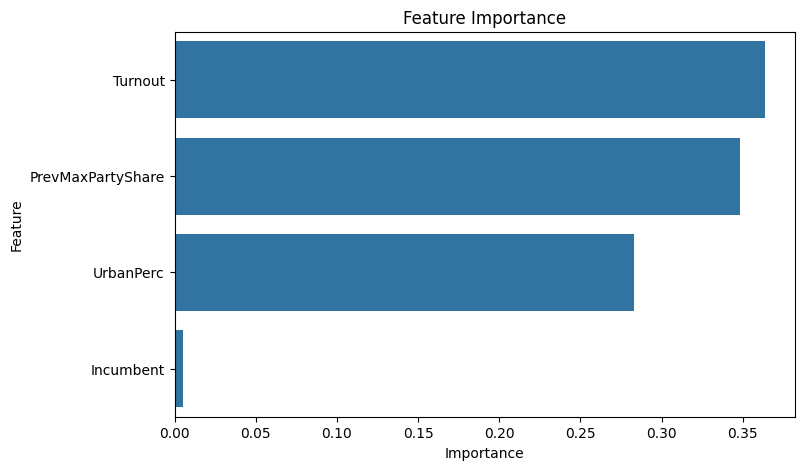

In [ ]:
def main():

    path_2019 = "/content/LS2019_results (2).csv"
    path_2024 = "/content/LS2024_results (1).csv"

    df = load_data(path_2019, path_2024)
    df = clean_data(df)
    df = feature_engineering(df)

    X_train, X_test, y_train, y_test, df = prepare_data(df)

    model = train_model(X_train, y_train)

    y_pred, cm = evaluate_model(model, X_test, y_test, df)

    visualize_results(cm, y_test, y_pred)

    feature_importance(
        model,
        ['PrevMaxPartyShare', 'Turnout', 'Incumbent', 'UrbanPerc']
    )

main()